# Control predictivo adaptativo

In [2]:

import numpy as np
import matplotlib.pyplot as plt
import control as ctrl
import scipy as sc
from scipy.signal import lfilter


## Simulación del control predictivo adaptativo directo

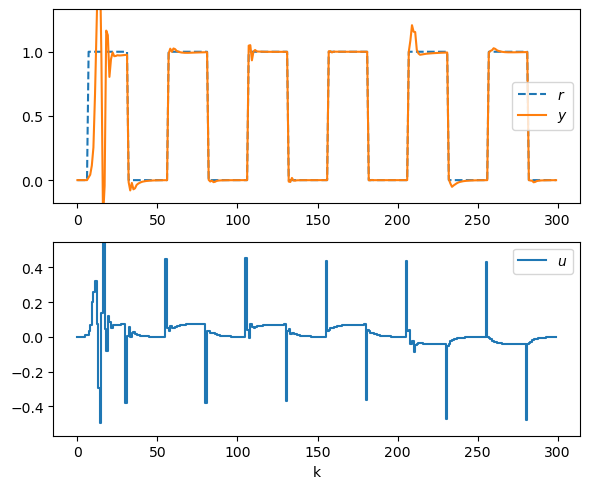

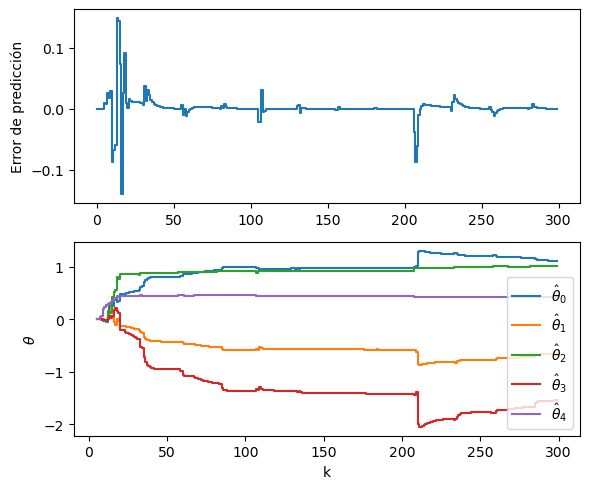

In [20]:
def simularControlPredictivoPonderadoAdaptativo(A, Bp, d, r, lambda_b0 = 0, alpha=0.95, deltaA=None, deltaB=None, plot=True, title=None):
    """
    Simula un controlador predictivo ponderado adaptativo (RLS) para un modelo ARX dado por A, Bp y delay d.

    Entradas:
      - A: vector de coeficientes del polinomio A (monico) [1, a1, a2, ...]
      - Bp: vector de coeficientes del polinomio B (numerador) (incluye b0, b1,...)
      - d: delay (nk) en muestras
      - r: referencia (vector de longitud N)
      - lambda_b0: factor de ponderación
      - alpha: factor de olvido para el RLS (0<alpha<=1)
      - deltaA, deltaB: vectores de perturbación en tiempo (opcional), si se proporcionan se aplican on-line
      - plot: si True dibuja resultados
      - title: título opcional para la figura

    Salidas:
      - y: salida simulada
      - u: señal de control
    """

    # copias locales del modelo (se pueden modificar en tiempo si se pasan deltaA/deltaB)
    A_ = A.copy()
    Bp_ = Bp.copy()

    na = len(A)          # orden A (número de coeficientes)
    nb = len(Bp)         # orden Bp

    # señales y variables
    N = len(r)
    k = np.arange(N)
    u = np.zeros(N)      # acción de control
    y = np.zeros(N)      # salida de la planta
    err = np.zeros(N)    # error de identificación (almacena errores en tiempo desplazado)

    # inicialización del estimador RLS para parámetros del controlador
    theta_hat = np.zeros(na + nb)   # vector de parámetros estimados
    theta_hat[-1] = 0.01            # pequeña semilla en el último parámetro
    theta_hist = []                 # historial de estimaciones (para plot)
    P = 100 * np.eye(na + nb)       # matriz de covarianza inicial grande (incertidumbre)

    # bucle de simulación: se itera desde d+na hasta N-1 para tener históricos suficientes
    for kk in range(d + na, N):
        # ===== Estimador (RLS) del controlador =====
        # Construcción del vector de regresores para estimar la relación entre phi y u
        # phiC_est contiene: salidas pasadas (con signo -), entradas pasadas (con signo -) y la salida presente y[kk]
        phiC_est = np.r_[
            -y[kk-d:kk-na+1-d:-1],                 # -y[k-d], -y[k-d-1], ...
            -u[kk-1-d:kk-nb-d+1-d:-1],             # -u[k-1-d], -u[k-2-d], ...
            y[kk]+lambda_b0 * u[kk-d]                                  # salida actual
        ]

        # error usado para la actualización del estimador (u medido menos predicho)
        # se almacena en err con desplazamiento kk-d para alinear tiempos
        err[kk-d] = u[kk-d] - phiC_est @ theta_hat

        # Ganancia de Kalman / actualización RLS
        K = (P @ phiC_est) / (alpha + phiC_est.T @ P @ phiC_est)
        theta_hat = theta_hat + K * err[kk-d]              # actualización de parámetros
        P = (P - np.outer(K, phiC_est) @ P) / alpha        # actualización de covarianza
        theta_hist.append(theta_hat.copy())

        # ===== Cálculo de la acción de control =====
        # Construcción del vector de regresores para la ley de control (phiC)
        # Contiene salidas pasadas, entradas pasadas y referencia futura (r[kk+d])
        phiC = np.r_[
            -y[kk:kk-na+1:-1],                         # -y[k], -y[k-1], ...
            -u[kk-1:kk-nb-d+1:-1],                     # -u[k-1], -u[k-2], ...
            (r[kk+d] if kk < N - d else r[-1])         # referencia a futuro (si existe) o último valor
        ]

        # acción de control según parámetros estimados actuales
        u[kk] = phiC @ theta_hat

        # ===== Aplicación de perturbaciones en el modelo (si se suministran) =====
        if deltaA is not None:
            # actualizar A_ multiplicando coeficientes a1.. por (1+deltaA[kk])
            A_[1:] = A[1:] * (1 + deltaA[kk])
        if deltaB is not None:
            # actualizar Bp_ multiplicando por (1+deltaB[kk])
            Bp_ = Bp * (1 + deltaB[kk])

        # ===== Simulación de la planta (modelo ARX) =====
        # parte autoregresiva de la salida: y_AR = - sum_{i=0}^{na-1} A_[i+1] * y[k-i]
        y_AR = np.dot(-A_[1:], y[kk:kk-na+1:-1])

        # parte dependiente de la entrada retrasada: usa Bp_ y la entrada con delay d
        y_X = np.dot(Bp_, u[kk-d+1:kk-d+1-nb:-1])

        # suma de términos para obtener la salida en el siguiente instante (si existe)
        if kk < N - 1:
            y[kk+1] = y_AR + y_X

    # ===== Resultados y gráficos opcionales =====
    if plot:
        plt.figure(figsize=(6, 5))
        plt.subplot(211)
        plt.plot(k, r, '--', label='$r$')
        plt.plot(k, y, label='$y$')
        ymin, ymax = np.min(y[int(N/3):]), np.max(y[int(N/3):])
        plt.ylim(ymin - 0.1*(ymax-ymin), ymax + 0.1*(ymax-ymin)); 
        if title is not None:
            plt.title(title)
        plt.legend()

        plt.subplot(212)
        plt.step(k, u, label='$u$', where='post')
        umin, umax = np.min(u[int(N/3):]), np.max(u[int(N/3):])
        plt.ylim(umin - 0.1*(umax-umin), umax + 0.1*(umax-umin));
        plt.legend()
        plt.xlabel("k")
        plt.tight_layout()
        plt.show()

        # convertir historial de thetas a array y mostrar evolución
        theta_hist = np.array(theta_hist)
        plt.figure(figsize=(6, 5))
        plt.subplot(211)
        plt.step(k, err, where='post')
        plt.ylabel('Error de predicción')
        if title is not None:
            plt.title('Estimación de parámetros')

        plt.subplot(212)
        for idx_n in range(0, na + nb):
            plt.step(k[-len(theta_hist):], theta_hist[:, idx_n], label=f"$\\hat{{\\theta}}_{idx_n}$", where='post')
        plt.xlabel("k")
        plt.ylabel('$\\theta$')
        plt.legend()
        plt.tight_layout()
        plt.show()

    return y, u

A = np.r_[1, -1.74, .77]
Bp = 2 * np.r_[1.1, -.9]
d = 2

N = 300
k = np.arange(N)
r = 0.5 * (sc.signal.square(2*np.pi * k / 50 - np.pi/4) + 1)

deltaA = np.zeros(N)
deltaB = np.zeros(N)
deltaA[int(N*2/3):] = 0.05
deltaB[int(N*1/3):] = 0.05

_,_ = simularControlPredictivoPonderadoAdaptativo(A,Bp,d,r,lambda_b0=0,deltaA=deltaA,deltaB=deltaB)

## Simulación sobre planta con cero negativo

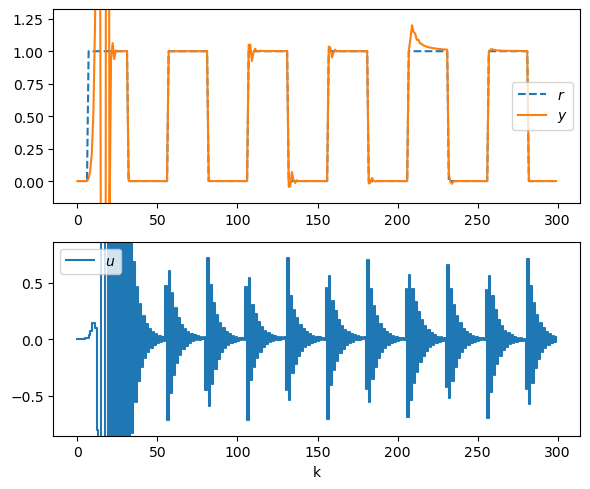

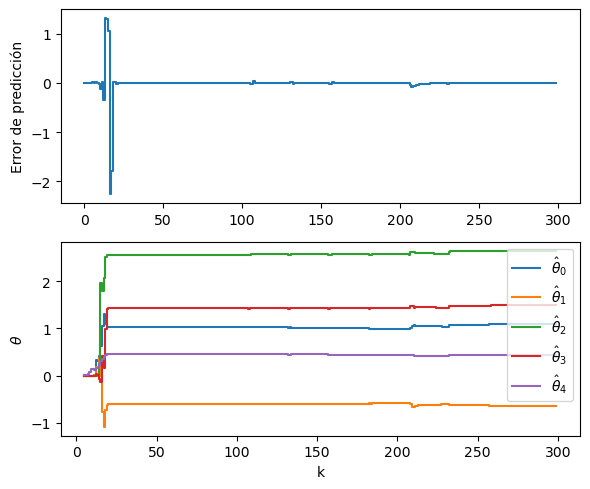

In [24]:
A = np.r_[1, -1.74, .77]
Bp = 2 * np.r_[1.1, .9]
d = 2

N = 300
k = np.arange(N)
r = 0.5 * (sc.signal.square(2*np.pi * k / 50 - np.pi/4) + 1)

deltaA = np.zeros(N)
deltaB = np.zeros(N)
deltaA[int(N*2/3):] = 0.05
deltaB[int(N*1/3):] = 0.05

_,_ = simularControlPredictivoPonderadoAdaptativo(A,Bp,d,r,deltaA=deltaA,deltaB=deltaB)

## Simulación del control predictivo ponderado adaptativo directo

Según lo visto en la simulación anterior, es necesario ponderar para limitar la acción de control

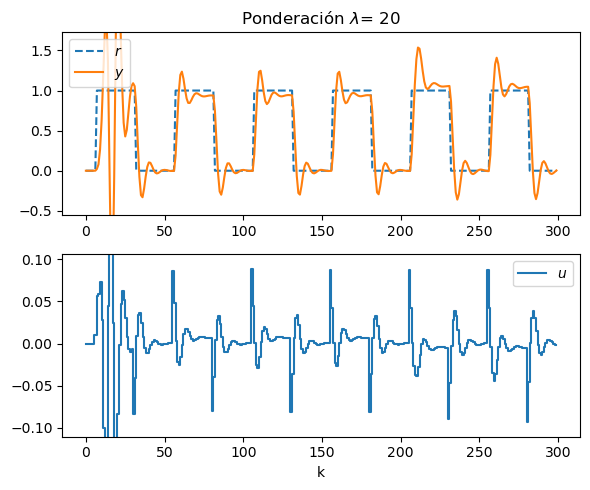

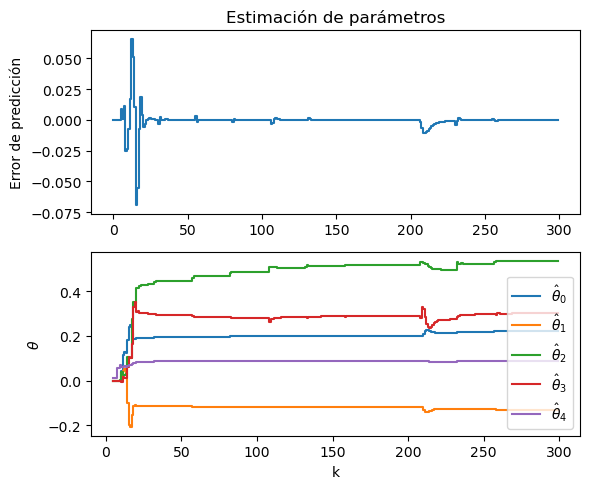

In [27]:
lambda_ = 20
lambda_b0 = lambda_ / Bp[0]
_,_ = simularControlPredictivoPonderadoAdaptativo(A,Bp,d,r,lambda_b0=lambda_b0,deltaA=deltaA,deltaB=deltaB, title=f'Ponderación $\lambda$= {lambda_}')